# MHMDS Example Usage Tutorial

This notebook provides hands-on examples of using MHMDS (Multiscale Hyperbolic Multidimensional Scaling) for embedding high-dimensional data into hyperbolic space.

## What You'll Learn

1. **Toggle Switch Example** (Feature Matrix): Synthetic gene regulatory network showing trajectory-like structure
2. **WordNet Mammals Example** (Distance Matrix): Hierarchical taxonomy demonstrating tree-like structure

## Prerequisites

- Python 3.8+ with required packages installed
- CmdStanPy 1.1.0 and compiled Stan models

## Notebook Structure

- **Cells 1-2**: Setup and helper functions
- **Cells 3-8**: Toggle Switch example
- **Cells 9-16**: WordNet Mammals example
- **Cells 17**: Guidelines and troubleshooting

Let's begin!

In [1]:
# Import required packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
from pathlib import Path
import glob
import sys

# Add MHMDS to path
sys.path.append('../')
import MHMDS.embed_funs as emb


print("✓ Imports successful")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

✓ Imports successful
NumPy version: 1.23.5
Pandas version: 2.0.3


# Example 1: Toggle Switch (Feature Matrix Workflow)

## Dataset Overview

The **Toggle Switch** dataset represents a synthetic gene regulatory network with bistable behavior - a classic system that can exist in two stable states.

**Key characteristics:**
- 200 cells (rows) × 2 gene expression features (columns)
- Two stable states (high A/low B and low A/high B)
- Intermediate transition states
- Trajectory-like structure in high-dimensional space

**What we'll do:**
1. Generate hierarchical clusters using K-means
2. Embed into 2D hyperbolic space
3. Visualize the bistable states and transitions
4. Analyze embedding quality

In [3]:
# Load Toggle Switch metadata
metadata_file = Path('../data/metadata/ToggleSwitch_metadata.csv')
metadata = pd.read_csv(metadata_file, index_col=0)

featmat_file = Path('../data/FeatMat_ToggleSwitch/FeatMat_ToggleSwitch.txt')
if featmat_file.exists():
    # Preview data dimensions
    with open(featmat_file) as f:
        first_line = f.readline().strip().split('\t')
        n_features = len(first_line)
    
    # Count lines
    with open(featmat_file) as f:
        n_samples = sum(1 for _ in f)
    
    print(f"Feature matrix ound: {n_samples} samples × {n_features} features")
else:
    print(f"Feature matrix not found at {featmat_file}")

Feature matrix ound: 200 samples × 1 features


## Step 1: Generate Hierarchical Clusters

Run this command in your terminal:

```bash
cd ../MultiscalehMDS_feature
python Generate_cls.py --featmat FeatMat_ToggleSwitch.txt --n-clusters 20
```

**What this does**:
- Performs K-means clustering on the feature matrix
- Creates a single hierarchical layer with 20 clusters
- Saves cluster assignments to `cls_20`

**To verify:** Check that the file `../data/FeatMat_ToggleSwitch/cls_20`  was created.

## Step 2: Run Multiscale Embedding

Run this command in your terminal (from the `MultiscalehMDS_feature` directory):

```bash
python Multiscale_hmds.py --featmat FeatMat_ToggleSwitch.txt --clusters cls_20 \
       --neighbors 10 --dimension 2 --min-cluster-size 1 --max-cluster-size 400 \
       --save-matrix --compute-metrics --outlier-neighbors 10
```

**Parameter explanation:**
- `--featmat FeatMat_ToggleSwitch.txt`: Input feature matrix
- `--clusters cls_20`: Use the cluster assignments we just generated
- `--neighbors 10`: Use 10 nearest neighbors for local geometry
- `--dimension 2`: Embed into 2D hyperbolic space for visualization
- `--min-cluster-size 1`: Minimum cluster size (1 = embed all samples)
- `--max-cluster-size 400`: Maximum cluster size before refining (to avoid too large clusters)

**Expected runtime**: ~2-5 seconds on a standard laptop

**Output location:** `./test/FeatMat_ToggleSwitch/`

**Expected files:**
- `cls_20_Nn_10_Nd_2_min_1_max_400_coords_20.txt`: Coordinates of cluster centroids (20 points)
- `cls_20_Nn_10_Nd_2_min_1_max_400_coords_200.txt`: Individual sample coordinates (200 points)
- `cls_20_Nn_10_Nd_2_min_1_max_400_inds_after_prep.txt`: index file
- `cls_20_Nn_10_Nd_2_min_1_max_400_metrics.csv`: quality metrics

In [4]:
# Load Toggle Switch embedding results
result_dir = '../MultiscalehMDS_feature/test/FeatMat_ToggleSwitch/'
prefix = 'cls_20_Nn_10_Nd_2_min_1_max_400'
nsample = 200

pcoords = np.loadtxt(result_dir+prefix+'_coords_%i.txt'%nsample)
inds = np.loadtxt(result_dir+prefix+'_inds_after_prep.txt')
pcoords = pcoords[np.argsort(inds)]

# print basic dimensions
print('Dimension of embedding: ', pcoords.shape)

# print embedding quality
metrics = pd.read_csv(result_dir+prefix+'_metrics.csv')
print(metrics.iloc[1,2:7])


Dimension of embedding:  (200, 2)
Qlocal              1.0
Qglobal        0.999953
corr                1.0
runningtime    2.756106
curvature      0.063193
Name: 1, dtype: object


19:37:18 - cmdstanpy - INFO - Chain [1] start processing
19:37:18 - cmdstanpy - INFO - Chain [1] done processing
19:37:18 - cmdstanpy - INFO - Chain [1] start processing
19:37:18 - cmdstanpy - INFO - Chain [1] done processing


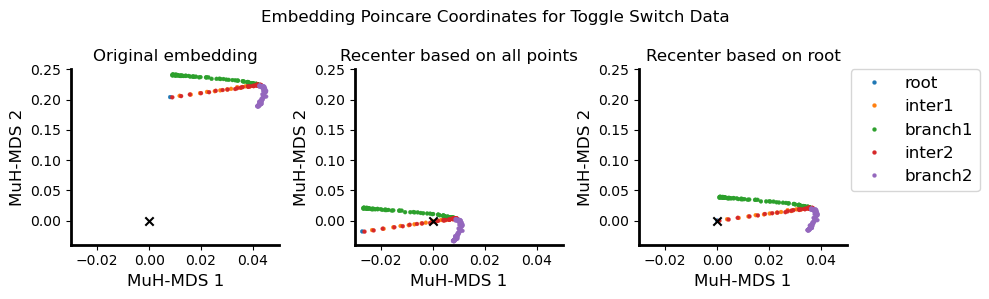

In [47]:
df_toplot = pd.concat([metadata.reset_index().iloc[:,1:],
                               pd.DataFrame(pcoords,columns=['x','y'])],axis=1)

# recenter based on center-of-mass of all points 
pcoords_rc = emb.perform_recenter(pcoords,np.arange(nsample))
df_toplot_rc = pd.concat([metadata.reset_index().iloc[:,1:],
                               pd.DataFrame(pcoords_rc,columns=['x','y'])],axis=1)

# recenter based on root node
rootind = np.where(metadata['labels']=='root')[0][0]
pcoords_rc_root = emb.perform_recenter(pcoords,np.array([rootind]))
df_toplot_rc_root = pd.concat([metadata.reset_index().iloc[:,1:],
                               pd.DataFrame(pcoords_rc_root,columns=['x','y'])],axis=1)
dfs = [df_toplot, df_toplot_rc, df_toplot_rc_root]
fig, axs = plt.subplots(1,3,figsize=(10,3))
titles = ['Original embedding', 'Recenter based on all points', 'Recenter based on root']
for i in range(3):
    sn.scatterplot(data=dfs[i],x='x',y='y',hue=metadata.columns[0],edgecolor=None,
                      s=8,ax=axs[i])
    axs[i].scatter([0],[0],marker='x',color='black')
    axs[i].spines['bottom'].set_linewidth(2)
    axs[i].spines['left'].set_linewidth(2)
    axs[i].spines[['right','top']].set_visible(False)
    axs[i].set_xlim(-0.03,0.05)
    axs[i].set_ylim(-0.04,0.25)
    axs[i].set_title(titles[i],fontsize=12)
    axs[i].set_xlabel('MuH-MDS 1',fontsize=12)
    axs[i].set_ylabel('MuH-MDS 2',fontsize=12)
    axs[i].legend([],[], frameon=False)
axs[2].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)
fig.suptitle('Embedding Poincare Coordinates for Toggle Switch Data', fontsize=12)
plt.tight_layout()
plt.savefig('./images/toggle_switch_embedding.png')

# Example 2: WordNet Mammals (Distance Matrix Workflow)

## Dataset Overview

The **WordNet Mammals** dataset represents a hierarchical taxonomy from the WordNet lexical database - a tree structure organizing mammal species by biological classification.

**Key characteristics:**
- 1180 mammal species from WordNet
- Tree-like hierarchical structure (order → family → genus → species)

**What we'll do:**
1. Generate hierarchical clusters using agglomerative clustering
2. Embed into 2D hyperbolic space
3. Visualize the taxonomic hierarchy
4. Analyze how hierarchy depth maps to radial distance

## Step 1: Generate Hierarchical Clusters

Run this command in your terminal:

```bash
cd ../MultiscalehMDS_distance
python Generate_cls.py --distmat DistMat_mammalwords.txt --thresholds 0.4
```

*Please refer to `WordNet/Fig2d.ipynb` for details on how we get from graph to distance matrix. In short, we computed the graph distance from the original Wordnet Mammal Tree*

**What this does:**
- Performs agglomerative (hierarchical) clustering on the distance matrix
- Cuts the dendrogram at distance threshold 0.4
- Saves cluster assignments to `cls_0.4`


## Step 2: Run Multiscale Embedding

Run this command in your terminal (from the `MultiscalehMDS_distance` directory):

```bash
python Multiscale_hmds.py --distmat DistMat_mammalwords.txt --clusters cls_0.4 \
       --neighbors 60 --dimension 2 --min-cluster-size 1 --max-cluster-size 300 \
       --save-matrix --compute-metrics --outlier-neighbors 10
```

**Parameter explanation:**
- `--distmat DistMat_mammalwords.txt`: Input distance matrix
- `--clusters cls_0.4`: Use the cluster assignments from threshold 0.4
- `--neighbors 60`: Use 60 neighbors (higher than Toggle Switch due to more samples)
- `--dimension 2`: Embed into 2D hyperbolic space
- `--min-cluster-size 1`: Embed all species
- `--max-cluster-size 300`: Maximum cluster size before refining

**Expected runtime**: ~1-2 minutes

**Output location:** `./test/DistMat_mammalwords/`

In [104]:
# Load WordNet mammals embedding results
result_dir_wn = '../MultiscalehMDS_distance/test/DistMat_mammalwords/'
prefix_wn = 'cls_0.4_Nn_60_Nd_2_min_1_max_300'
nsample = 1180

pcoords = np.loadtxt(result_dir_wn+prefix_wn+'_coords_%i.txt'%nsample)
inds = np.loadtxt(result_dir_wn+prefix_wn+'_inds_after_prep.txt')
pcoords = pcoords[np.argsort(inds)]

# recenter
pcoords = emb.perform_recenter(pcoords,np.arange(nsample))

# print basic dimensions
print('Dimension of embedding: ', pcoords.shape)

# print embedding quality
metrics = pd.read_csv(result_dir_wn+prefix_wn+'_metrics.csv')
print(metrics.iloc[1,2:7])

20:14:49 - cmdstanpy - INFO - Chain [1] start processing
20:14:49 - cmdstanpy - INFO - Chain [1] done processing


Dimension of embedding:  (1180, 2)
Qlocal          0.492273
Qglobal          0.82892
corr            0.805028
runningtime    29.006125
curvature        6.69705
Name: 1, dtype: object


In [105]:
# load metadata
metadata_wn = pd.read_csv('../data/metadata/mammalwords_metadata.csv',index_col=0)
metadata_wn.head()

,num_children
bengal_tiger.n.01,NaN
tiger.n.02,3.0
carnivore.n.01,365.0
placental.n.01,1131.0
anthropoid_ape.n.01,15.0


In [106]:
# visualize embedding
df_toplot = pd.DataFrame({'x':pcoords[:,0],'y':pcoords[:,1]})
df_toplot = pd.concat([metadata_wn.reset_index().iloc[:,:],
                               df_toplot],axis=1)
df_toplot.head()

,index,num_children,x,y
0,bengal_tiger.n.01,NaN,-0.506825,0.819051
1,tiger.n.02,3.0,-0.483993,0.767616
2,carnivore.n.01,365.0,-0.195900,-0.393527
3,placental.n.01,1131.0,-0.176219,0.034996
4,anthropoid_ape.n.01,15.0,-0.543241,-0.577772


In [107]:
# visualize embedding: poincare coordinate and native coordinates
native = emb.to_native(pcoords)
df_toplot['nativex'] = native[:,0]
df_toplot['nativey'] = native[:,1]

df_toplot.set_index('index',inplace=True)

# name to note
namelist = df_toplot.sort_values(by='num_children', ascending=False).index[:30].to_list()
print(namelist)

['mammal.n.01', 'placental.n.01', 'carnivore.n.01', 'ungulate.n.01', 'canine.n.02', 'dog.n.01', 'even-toed_ungulate.n.01', 'ruminant.n.01', 'rodent.n.01', 'bovid.n.01', 'odd-toed_ungulate.n.01', 'equine.n.01', 'primate.n.02', 'hunting_dog.n.01', 'horse.n.01', 'aquatic_mammal.n.01', 'feline.n.01', 'working_dog.n.01', 'musteline_mammal.n.01', 'bat.n.01', 'bovine.n.01', 'monkey.n.01', 'cat.n.01', 'terrier.n.01', 'metatherian.n.01', 'marsupial.n.01', 'antelope.n.01', 'carnivorous_bat.n.01', 'cetacean.n.01', 'whale.n.02']


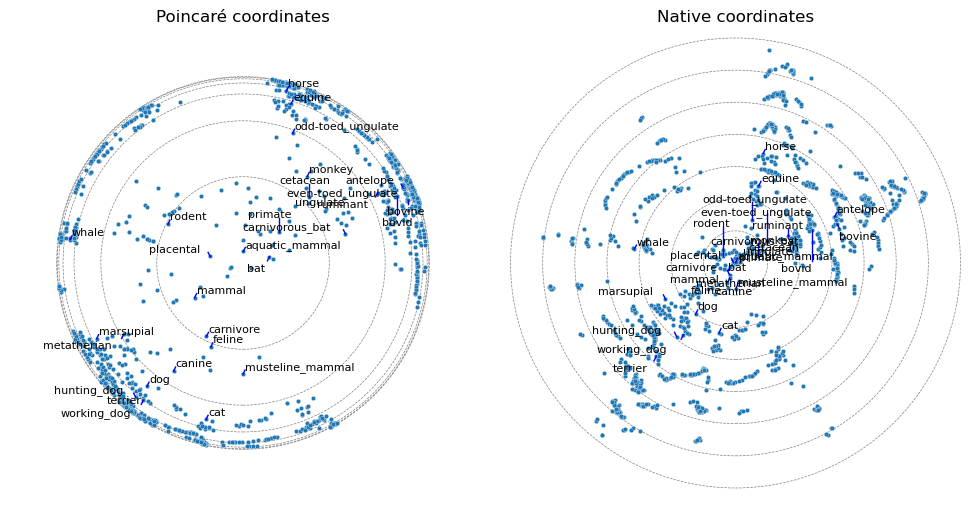

In [114]:
# plot edges
fig,axs = plt.subplots(1,2,figsize=(10,5))
for i,mode in enumerate(['poin','native']):
    # plot circles at (0,0) of different radius to indicate hyperbolic
    maxradius = np.ceil(np.max(np.sqrt(df_toplot['nativex']**2 + df_toplot['nativey']**2)))
    rads = np.arange(1,maxradius + 1, 1)
    if mode == 'poin':
        rads = np.tanh(rads/2.0)
    for r in rads:
        circle = plt.Circle((0, 0), r, color='gray', fill=False, linestyle='--', linewidth=0.5)
        axs[i].add_artist(circle)
    xtoplot = 'x' if mode == 'poin' else 'nativex'
    ytoplot = 'y' if mode == 'poin' else 'nativey'

    sc = axs[i].scatter(
        df_toplot[xtoplot], df_toplot[ytoplot],
        # c=colors,
        s=10,
        alpha=1.0,
        edgecolors='white',
        linewidths=0.2
    )

    import textalloc as ta
    ta.allocate_text(fig,axs[i],df_toplot.loc[namelist][xtoplot],
                    df_toplot.loc[namelist][ytoplot],
                [name.split('.')[0] for name in namelist],
                max_distance=0.05,
                min_distance=0.005,
                margin=0.0,
                linewidth=1,
                nbr_candidates=200,
                linecolor='blue',
                    textsize=8,
                    avoid_label_lines_overlap=True,
                    seed=3)

    # set x and y limits
    axs[i].set_xlim(-rads[-1]-0.25, rads[-1]+0.25)
    axs[i].set_ylim(-rads[-1]-0.25, rads[-1]+0.25)

    # remove axis and box
    axs[i].set_axis_off()
    # set aspect ratio to equal
    axs[i].set_aspect('equal', adjustable='box')

axs[0].set_title('Poincaré coordinates', fontsize=12)
axs[1].set_title('Native coordinates', fontsize=12)
plt.tight_layout()
plt.savefig('./images/wordnet_mammals_embedding.png',dpi=300)

## Resources

- **Parameter tuning**: See [3-Parameters.md](3-Parameters.md) for detailed guidance
- **Algorithm details**: See [1-Overview.md](1-Overview.md) for mathematical background
- **Code reference**: Explore the `MHMDS/` directory for core functions
- **Paper**: See the manuscript for theoretical foundations and benchmarks

**Happy embedding! 🎉**